# 04 — Datenbereinigung (Multiple Imputation)

Dieses Notebook bereinigt die in **Notebook 03** erstellte Roh-Panel-Datenbank
`Created DBs/final_database_raw.csv` (**1904** Zeilen = 119 Länder × 16 Jahre 2007–2022;
2 Zielvariablen + 37 Features).

**Methodischer Rahmen**
- Geplant ist eine **Multiple Imputation** (Amelia bzw. `mice`) der **Features**.
  Die **Zielvariablen (HDI, Happiness_Score) werden NICHT imputiert.**
- **Dieser erste Schritt** legt die Diagnose-Grundlage: eine **Land × Variable-Missingness-Map**
  (`Amelia::missmap` / `naniar::vis_miss` + aggregierte Heatmap) und die **exakte Zählung**,
  bei wie vielen Ländern eine Variable *komplett* (alle 16 Jahre) fehlt.
- **Strukturelle Lücken** (Land ganz ohne Variable) sind durch zeitliche Verfahren **nicht**
  schließbar und müssen in der Imputationsstrategie gesondert behandelt werden.

> Umgebung: **R** (Kernel `ir`). Eingelesen wird die CSV aus NB 03; fehlende Werte sind dort
> als `n/a` kodiert.

## 0 — Setup

In [51]:
# ── Bibliotheken ───────────────────────────────────────────────────────
suppressPackageStartupMessages({
  library(readr)    # CSV-Einlesen
  library(dplyr)    # Datenmanipulation
  library(tidyr)    # pivot_longer
  library(ggplot2)  # Heatmap
  library(naniar)   # vis_miss / Missingness-Diagnostik
  library(Amelia)   # missmap + (spätere) Multiple Imputation
  library(writexl)  # Excel-Export der Übersichten
})

set.seed(42)  # Reproduzierbarkeit
options(repr.plot.width = 11, repr.plot.height = 7)  # Plotgröße im Notebook

# ── Pfade (Arbeitsverzeichnis = code/, analog zu NB 03) ────────────────
RAW_PATH  <- file.path("..", "Created DBs", "final_database_raw.csv")
OUTPUT_DB <- file.path("..", "Created DBs")

# ── Roh-DB einlesen (fehlende Werte sind als 'n/a' kodiert) ────────────
df <- readr::read_csv(
  RAW_PATH,
  na = c("", "NA", "n/a", "N/A"),
  show_col_types = FALSE
)

cat(sprintf("Eingelesen: %d Zeilen x %d Spalten\n", nrow(df), ncol(df)))
cat(sprintf("Zeitraum: %d-%d | Laender: %d\n",
            min(df$Year), max(df$Year), dplyr::n_distinct(df$ISO3)))

Eingelesen: 1904 Zeilen x 42 Spalten
Zeitraum: 2007-2022 | Laender: 119


## 1 — Datenstruktur & Spaltenrollen

In [52]:
# ── Spaltenrollen festlegen ────────────────────────────────────────────
id_cols      <- c("ISO3", "Country_Name", "Year")
target_cols  <- c("HDI", "Happiness_Score")
feature_cols <- setdiff(names(df), c(id_cols, target_cols))
value_cols   <- c(target_cols, feature_cols)

N_COUNTRIES <- dplyr::n_distinct(df$ISO3)
N_YEARS     <- dplyr::n_distinct(df$Year)

cat(sprintf("ID-Spalten    : %d  (%s)\n", length(id_cols), paste(id_cols, collapse = ", ")))
cat(sprintf("Zielvariablen : %d  (%s) -- werden NICHT imputiert\n",
            length(target_cols), paste(target_cols, collapse = ", ")))
cat(sprintf("Features      : %d\n", length(feature_cols)))

# ── Gesamt-Fehlanteil ──────────────────────────────────────────────────
n_miss_feat  <- sum(is.na(df[feature_cols]))
n_cells_feat <- nrow(df) * length(feature_cols)
cat(sprintf("\nFehlende Feature-Zellen: %d von %d (%.1f%%)\n",
            n_miss_feat, n_cells_feat, 100 * n_miss_feat / n_cells_feat))
cat(sprintf("Fehlende Zielwerte -> HDI: %d | Happiness_Score: %d\n",
            sum(is.na(df$HDI)), sum(is.na(df$Happiness_Score))))

ID-Spalten    : 3  (ISO3, Country_Name, Year)
Zielvariablen : 2  (HDI, Happiness_Score) -- werden NICHT imputiert
Features      : 37

Fehlende Feature-Zellen: 6889 von 70448 (9.8%)
Fehlende Zielwerte -> HDI: 0 | Happiness_Score: 123


## 2 — Land × Variable: Missingness-Map

Drei Sichten auf dieselbe Lücken-Struktur:
- **2a** `Amelia::missmap` — alle Land-Jahr-Beobachtungen × Variablen
- **2b** `naniar::vis_miss` — Fehlanteil je Variable über alle Beobachtungen
- **2c** aggregierte **Land × Variable**-Heatmap (Anteil fehlender Jahre je Land/Feature) —
  macht **strukturelle Lücken** (ganzes Land ohne Variable) unmittelbar sichtbar.

### 2a — `Amelia::missmap`

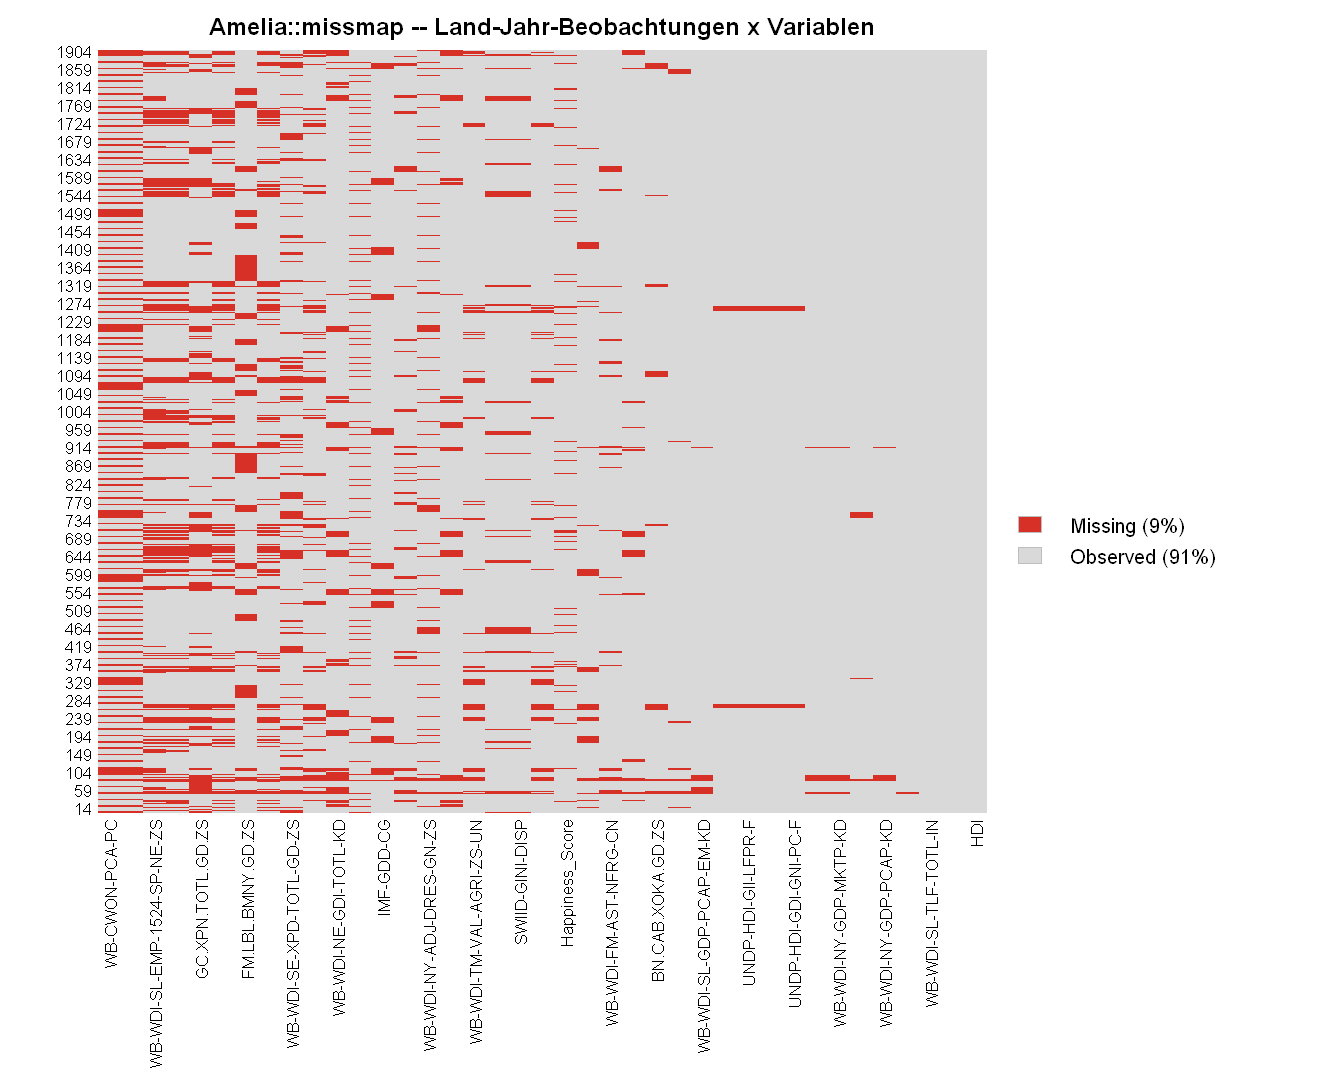

In [53]:
options(repr.plot.width = 11, repr.plot.height = 9)
Amelia::missmap(
  as.data.frame(df[value_cols]),
  main       = "Amelia::missmap -- Land-Jahr-Beobachtungen x Variablen",
  col        = c("#d73027", "grey85"),   # fehlend / beobachtet
  rank.order = TRUE,
  margins    = c(11, 4)
)

### 2b — `naniar::vis_miss`

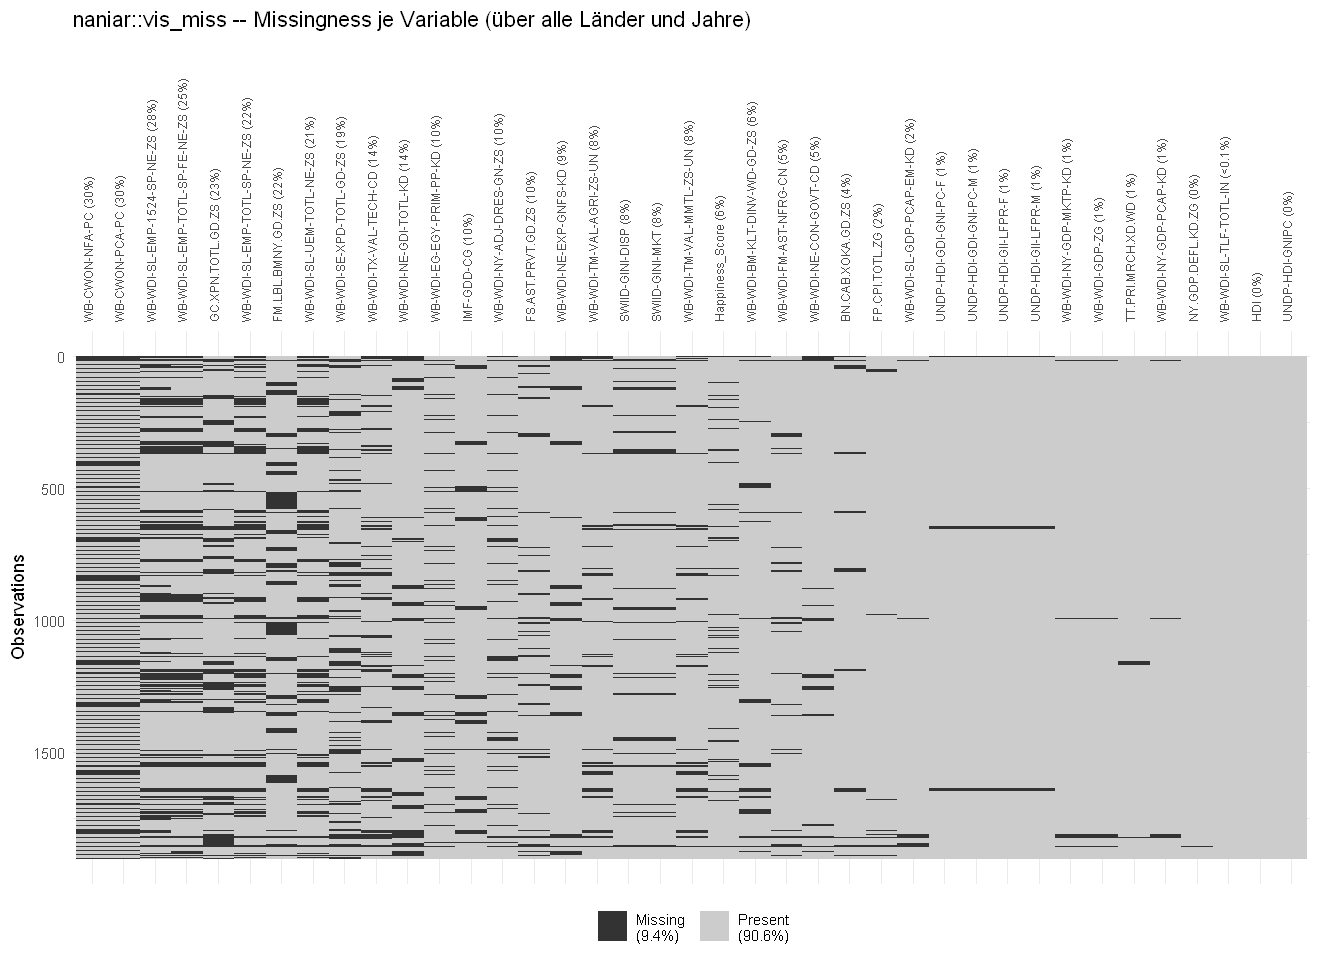

In [54]:
options(repr.plot.width = 11, repr.plot.height = 8)
naniar::vis_miss(df[value_cols], sort_miss = TRUE, warn_large_data = FALSE) +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 0, size = 7)) +
  ggplot2::labs(title = "naniar::vis_miss -- Missingness je Variable (über alle Länder und Jahre)")

## 3 — Exakte Zählung: komplett fehlende Länder je Variable

Eine Variable gilt für ein Land als **komplett fehlend**, wenn in **allen 16 Jahren** kein Wert
vorliegt. Dies ist die Grundlage für die Behandlung **struktureller Lücken** in der Imputation.

In [ ]:
# Logische Matrix Land x Feature: TRUE = Land hat fuer Feature keinen einzigen Wert
iso <- sort(unique(df$ISO3))
allna_mat <- sapply(feature_cols, function(v)
  tapply(df[[v]], df$ISO3, function(x) all(is.na(x)))[iso])
rownames(allna_mat) <- iso

# Tabelle je Variable
cm_var <- data.frame(
  Variable           = feature_cols,
  n_Länder_komplett_fehlend = as.integer(colSums(allna_mat)),
  Anteil_Länder_pct = round(100 * colSums(allna_mat) / length(iso), 1),
  Länder            = vapply(feature_cols,
                              function(v) paste(iso[allna_mat[, v]], collapse = ", "),
                              character(1)),
  row.names = NULL, stringsAsFactors = FALSE
)
cm_var <- cm_var[order(-cm_var$n_Länder_komplett_fehlend), ]

# Kennzahlen
n_pairs      <- sum(allna_mat)          # (Land,Variable)-Paare komplett fehlend
struct_cells <- n_pairs * N_YEARS       # entsprechende Zellen
cat(sprintf("Variablen mit >=1 komplett fehlendem Land: %d von %d\n",
            sum(cm_var$n_Länder_komplett_fehlend > 0), length(feature_cols)))
cat(sprintf("(Land,Variable)-Paare komplett fehlend: %d  ->  %d strukturelle Zellen (%.0f%% aller fehlenden Feature-Zellen)\n",
            n_pairs, struct_cells, 100 * struct_cells / n_miss_feat))

cm_var

In [ ]:
# Gegenstück: wie viele Variablen fehlen je Land komplett?
cm_country <- data.frame(
  ISO3                 = iso,
  n_Variablen_komplett_fehlend = as.integer(rowSums(allna_mat)),
  row.names = NULL, stringsAsFactors = FALSE
)
cm_country$Country_Name <- df$Country_Name[match(cm_country$ISO3, df$ISO3)]
cm_country <- cm_country[order(-cm_country$n_Variablen_komplett_fehlend),
                         c("ISO3", "Country_Name", "n_Variablen_komplett_fehlend")]

cat(sprintf("Laender mit >=1 komplett fehlender Variable: %d von %d\n",
            sum(cm_country$n_Variablen_komplett_fehlend > 0), length(iso)))
head(cm_country, 25)

Laender mit >=1 komplett fehlender Variable: 57 von 119


,ISO3,Country_Name,n_Variablen_komplett_fehlend
,<chr>,<chr>,<int>
114,VEN,"Venezuela, RB",8
103,TCD,Chad,6
73,MNE,Montenegro,5
79,NGA,Nigeria,5
1,AFG,Afghanistan,4
21,CHN,China,4
44,HKG,"Hong Kong SAR, China",4
26,CYP,Cyprus,3
76,MWI,Malawi,3


### Export der Übersichten

Beide Tabellen (`cm_var`, `cm_country`) werden in **eine** Excel-Datei mit zwei Tabellenblättern
geschrieben — Ablage in `Created Files for Analysis/missingness_uebersicht.xlsx`.

In [ ]:
# ── Export: beide Übersichten in EINE Excel-Datei (zwei Tabellenblätter) ──
ANALYSIS_DIR <- file.path("Created Files for Analysis")
xlsx_path    <- file.path(ANALYSIS_DIR, "missingness_uebersicht.xlsx")

writexl::write_xlsx(
  list(
    "Komplett_fehlend_je_Variable" = cm_var,      # je Feature (37 Zeilen)
    "Komplett_fehlend_je_Land"     = cm_country   # je Land   (119 Zeilen)
  ),
  path = xlsx_path
)

cat("Gespeichert:", normalizePath(xlsx_path), "\n")
cat(sprintf("  Blatt 1 'Komplett_fehlend_je_Variable': %d Zeilen x %d Spalten\n",
            nrow(cm_var), ncol(cm_var)))
cat(sprintf("  Blatt 2 'Komplett_fehlend_je_Land'    : %d Zeilen x %d Spalten\n",
            nrow(cm_country), ncol(cm_country)))